# Exploratory Data Analysis & Profiling

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### CSV Separator Issue

**Problem:**
The dataset was loaded with 50,000 rows and only 1 column instead of 10 columns.

**Cause:**
The CSV file uses a semicolon (`;`) as the column separator, while `pd.read_csv()` expects a comma by default.

**Solution:**
Specify the separator when loading the CSV:

```python
df = pd.read_csv("../data/raw/candidates.csv", sep=";")
```

**Key Lesson:**
Always check the dataset structure after loading it using `df.shape` and `df.info()`. The `sep` parameter tells Pandas how the columns are separated.


In [18]:
df = pd.read_csv("../data/raw/candidates.csv", sep=";")

In [19]:
# The first 5 rows of the dataframe
df.head()



,First Name,Last Name,Email,Application Date,Country,YOE,Seniority,Technology,Code Challenge Score,Technical Interview Score
0,Bernadette,Langworth,leonard91@yahoo.com,2021-02-26,Norway,2,Intern,Data Engineer,3,3
1,Camryn,Reynolds,zelda56@hotmail.com,2021-09-09,Panama,10,Intern,Data Engineer,2,10
2,Larue,Spinka,okey_schultz41@gmail.com,2020-04-14,Belarus,4,Mid-Level,Client Success,10,9
3,Arch,Spinka,elvera_kulas@yahoo.com,2020-10-01,Eritrea,25,Trainee,QA Manual,7,1
4,Larue,Altenwerth,minnie.gislason@gmail.com,2020-05-20,Myanmar,13,Mid-Level,Social Media Community Management,9,7


## DATA QUALITY

After analyzing the dataset, we can see that:

* **Null records:** None found.
* **Duplicate records:** None found.

The dataset contains no null or duplicate records, so no additional cleaning was required for these quality checks.


In [20]:
print(f"Dataset Shape: {df.shape}")
print("-" * 50)
df.info()

Dataset Shape: (50000, 10)
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   First Name                 50000 non-null  str  
 1   Last Name                  50000 non-null  str  
 2   Email                      50000 non-null  str  
 3   Application Date           50000 non-null  str  
 4   Country                    50000 non-null  str  
 5   YOE                        50000 non-null  int64
 6   Seniority                  50000 non-null  str  
 7   Technology                 50000 non-null  str  
 8   Code Challenge Score       50000 non-null  int64
 9   Technical Interview Score  50000 non-null  int64
dtypes: int64(3), str(7)
memory usage: 3.8 MB


In [21]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Number of duplicate rows: 0


## Candidate Overview

The dataset contains **50,000 candidates** with diverse levels of professional experience, ranging from **0 to 30 years of experience**.

Regarding technical assessments:

* **Code Challenge:** Average score of **5.0/10**
* **Technical Interview:** Average score of **5.0/10**

Overall, the results show that candidates' technical performance is concentrated around the **middle of the scoring scale**, with considerable variation between candidates.


In [22]:
print(df.describe())

                YOE  Code Challenge Score  Technical Interview Score
count  50000.000000          50000.000000               50000.000000
mean      15.286980              4.996400                   5.003880
std        8.830652              3.166896                   3.165082
min        0.000000              0.000000                   0.000000
25%        8.000000              2.000000                   2.000000
50%       15.000000              5.000000                   5.000000
75%       23.000000              8.000000                   8.000000
max       30.000000             10.000000                  10.000000


In [23]:

# Check the number of unique values for each column
df.nunique()



First Name                    3007
Last Name                      474
Email                        49833
Application Date              1646
Country                        244
YOE                             31
Seniority                        7
Technology                      24
Code Challenge Score            11
Technical Interview Score       11
dtype: int64

In [24]:
unique_percentage = (df.nunique() / len(df) * 100).round(2)

print(unique_percentage)

First Name                    6.01
Last Name                     0.95
Email                        99.67
Application Date              3.29
Country                       0.49
YOE                           0.06
Seniority                     0.01
Technology                    0.05
Code Challenge Score          0.02
Technical Interview Score     0.02
dtype: float64


## 📧 Email Duplicates and Inconsistencies

* **Total duplicated email records:** 167
* **Emails with inconsistent information:** 165
* **Complete duplicate rows:** 0

The dataset contains **50,000 candidate records** and no complete duplicate rows were identified. However, the analysis found **167 records with duplicated email addresses**.

To investigate these duplicated emails, the records were grouped by `Email` and the number of unique values was calculated for each candidate attribute. An email was considered inconsistent when at least one associated attribute contained more than one unique value.

The analysis identified **165 email addresses with inconsistent information**. For these emails, differences were found across multiple attributes, including:

* First Name
* Last Name
* Application Date
* Country
* YOE
* Seniority
* Technology
* Code Challenge Score
* Technical Interview Score

For example, the analysis shows that duplicated emails can have **different names, countries, years of experience, seniority levels, technologies, and assessment scores** associated with the same email address.

This suggests that the dataset contains **synthetically generated or logically inconsistent records**. In a real-world recruitment system, an email address would generally be expected to identify the same candidate, so significant differences across candidate attributes would require further investigation.

### 🔎 Key Findings

| Data Quality Check          | Result |
| --------------------------- | -----: |
| Total records               | 50,000 |
| Complete duplicate rows     |      0 |
| Duplicated email records    |    167 |
| Emails with inconsistencies |    165 |
| Unique emails               | 49,833 |

Overall, the dataset has no complete duplicate rows, but the **high proportion of inconsistent duplicated emails** indicates a potential data quality issue that should be considered during the data cleaning and transformation stages.


In [25]:
df.duplicated(subset=['Email']).sum()

np.int64(167)

In [26]:
# Detect duplicated emails
duplicated_emails = df[df.duplicated(subset='Email', keep=False)]

# Check for inconsistencies in duplicated emails
email_inconsistencies = duplicated_emails.groupby('Email').nunique()

# Filter to see where there are inconsistencies (more than 1 unique value for any column)
inconsistent_rows = email_inconsistencies[(email_inconsistencies > 1).any(axis=1)]

# Display inconsistencies
print(f"Number of email inconsistencies: {len(inconsistent_rows)}")
print(inconsistent_rows)



Number of email inconsistencies: 165
                          First Name  Last Name  Application Date  Country  \
Email                                                                        
abbigail94@yahoo.com               2          2                 2        2   
addison_bode@hotmail.com           2          2                 2        2   
alberta95@gmail.com                2          2                 2        2   
alberto11@yahoo.com                2          2                 2        2   
alejandra17@hotmail.com            2          2                 2        2   
...                              ...        ...               ...      ...   
velva76@hotmail.com                2          2                 2        2   
vern44@hotmail.com                 2          2                 2        2   
wilhelm76@hotmail.com              2          2                 2        2   
winston14@hotmail.com              2          2                 2        2   
zachery86@yahoo.com        

In [27]:
# Emails that appear more than once
duplicated_emails = df[df.duplicated(subset="Email", keep=False)]

# Check only identity-related fields
email_inconsistencies = (
    duplicated_emails
    .groupby("Email")[["First Name", "Last Name", "Country"]]
    .nunique()
)

# An email is inconsistent if any of these fields has more than one value
inconsistent_rows = email_inconsistencies[
    (email_inconsistencies > 1).any(axis=1)
]

print("Number of email inconsistencies:", len(inconsistent_rows))
print(inconsistent_rows)

Number of email inconsistencies: 165
                          First Name  Last Name  Country
Email                                                   
abbigail94@yahoo.com               2          2        2
addison_bode@hotmail.com           2          2        2
alberta95@gmail.com                2          2        2
alberto11@yahoo.com                2          2        2
alejandra17@hotmail.com            2          2        2
...                              ...        ...      ...
velva76@hotmail.com                2          2        2
vern44@hotmail.com                 2          2        2
wilhelm76@hotmail.com              2          2        2
winston14@hotmail.com              2          2        2
zachery86@yahoo.com                2          2        2

[165 rows x 3 columns]


### 6. Application Date Range

The `Application Date` field ranges from **January 1, 2018 to July 4, 2022**. All dates were successfully parsed, with **0 unparseable dates**.

In [28]:
dates = pd.to_datetime(df["Application Date"], errors="coerce")

print("Min date:", dates.min().date())
print("Max date:", dates.max().date())
print("Unparseable dates:", dates.isna().sum())

Min date: 2018-01-01
Max date: 2022-07-04
Unparseable dates: 0


In [29]:
score_columns = [
    "Code Challenge Score",
    "Technical Interview Score"
]

for col in score_columns:
    print(f"{col}:")
    print(f"Min: {df[col].min()}")
    print(f"Max: {df[col].max()}")

Code Challenge Score:
Min: 0
Max: 10
Technical Interview Score:
Min: 0
Max: 10


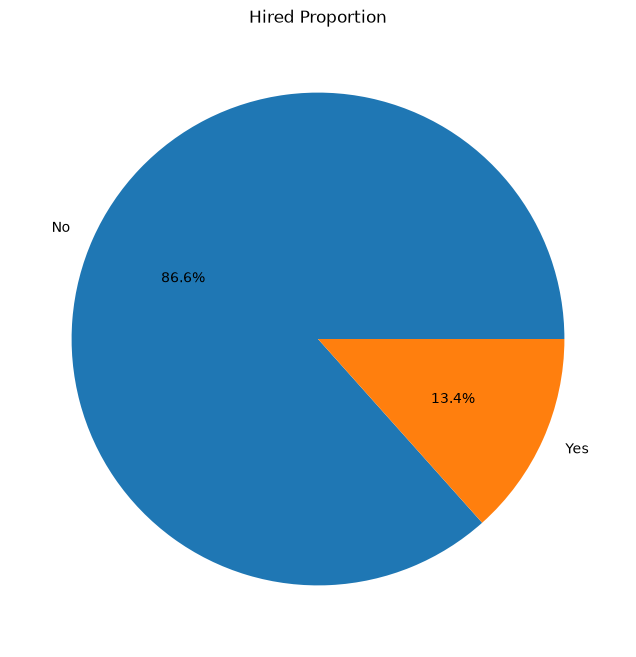

In [30]:
df["Hired"] = np.where(
    (df["Code Challenge Score"] >= 7)
    & (df["Technical Interview Score"] >= 7),
    "Yes",
    "No",
)

hired_count = df["Hired"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    hired_count,
    labels=hired_count.index,
    autopct="%1.1f%%"
)

plt.title("Hired Proportion")
plt.show()


Total Applications: 50000


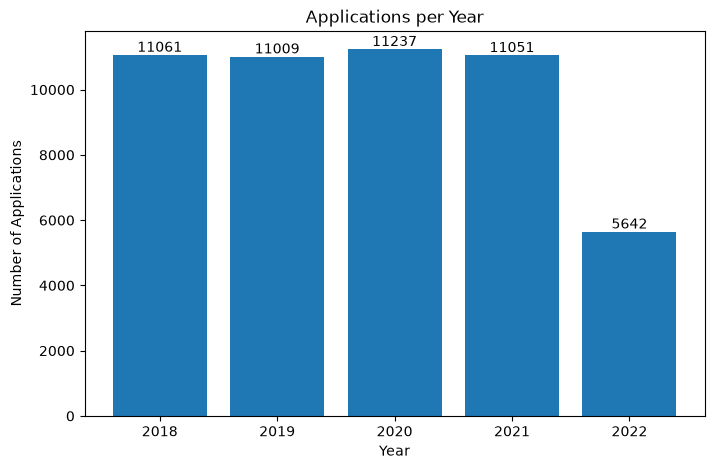

In [31]:
applications_per_year = dates.dt.year.value_counts().sort_index()

# Total number of applications
total_applications = applications_per_year.sum()

print(f"Total Applications: {total_applications}")

plt.figure(figsize=(8, 5))

plt.bar(applications_per_year.index, applications_per_year.values)

plt.title("Applications per Year")
plt.xlabel("Year")
plt.ylabel("Number of Applications")
plt.xticks(applications_per_year.index)

for year, count in applications_per_year.items():
    plt.text(year, count, str(count), ha="center", va="bottom")

plt.show()

The YOE distribution ranges from **0 to 30 years**, with a median of **15 years**. The middle 50% of candidates have between **8 and 23 years of experience**, indicating a relatively wide distribution of experience levels.

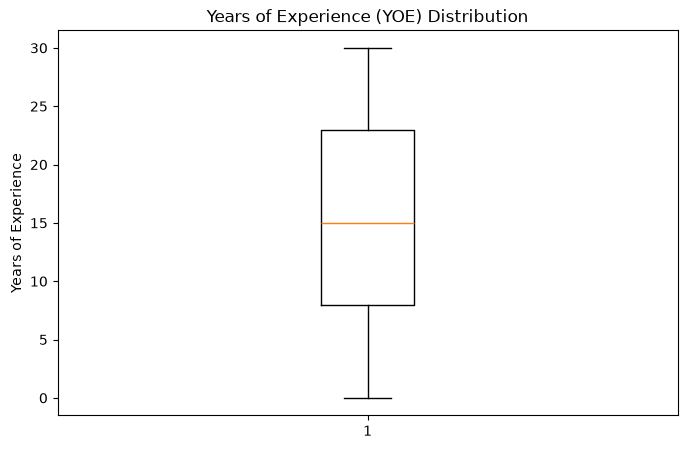

In [32]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["YOE"].dropna())

plt.title("Years of Experience (YOE) Distribution")
plt.ylabel("Years of Experience")

plt.show()